# Introduction to pandas, visualizing Titanic

## Master 2 TSE

#### Raphaël Sourty

In [ ]:
import pandas as pd

#### You can download the data here: https://www.kaggle.com/c/titanic/data

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


| Variable 	| Definition                                 	| Key                                            	|
|----------	|--------------------------------------------	|------------------------------------------------	|
| survival 	| Survival                                   	| 0 = No, 1 = Yes                                	|
| pclass   	| Ticket class                               	| 1 = 1st, 2 = 2nd, 3 = 3rd                      	|
| sex      	| Sex                                        	|                                                	|
| Age      	| Age in years                               	|                                                	|
| sibsp    	| # of siblings / spouses aboard the Titanic 	|                                                	|
| parch    	| # of parents / children aboard the Titanic 	|                                                	|
| ticket   	| Ticket number                              	|                                                	|
| fare     	| Passenger fare                             	|                                                	|
| cabin    	| Cabin number                               	|                                                	|
| embarked 	| Port of Embarkation                        	| C = Cherbourg, Q = Queenstown, S = Southampton 	|

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Who are the survivors of the Titanic?

#### Survival rate

In [ ]:
df.groupby('Survived')['PassengerId'].agg(['count'])

,count
Survived,
0,549
1,342


<Axes: xlabel='Survived'>

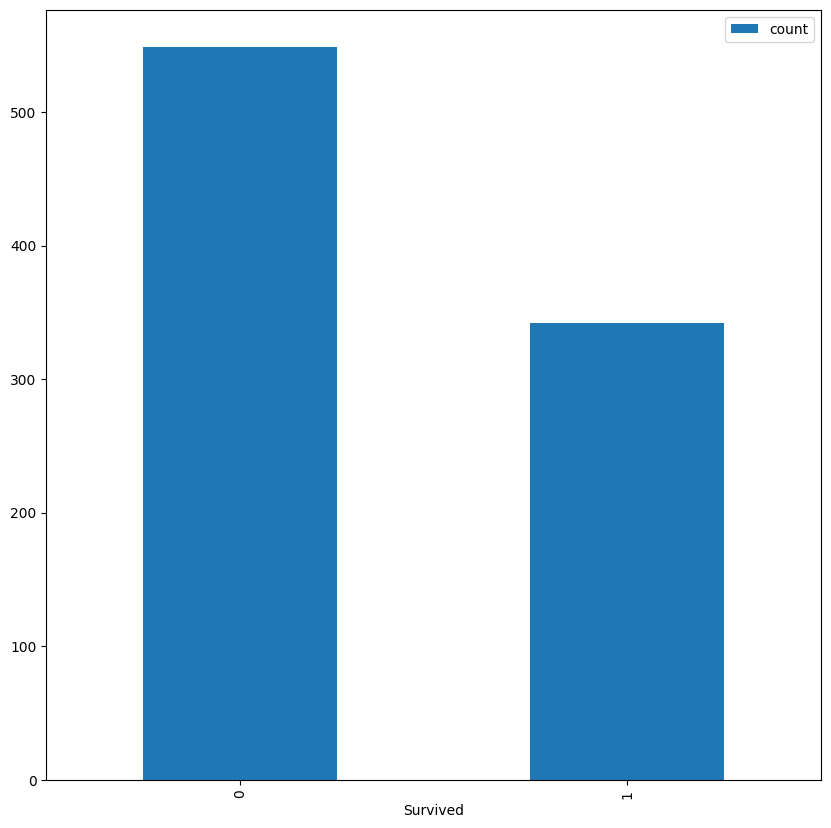

In [ ]:
df.groupby('Survived')['PassengerId'].agg(
    ['count']
).reset_index().plot(x='Survived', y='count', kind = 'bar', figsize = (10, 10))

#### Survival rate depending on genre

In [ ]:
df.groupby(
    ['Survived', 'Sex']
)['PassengerId'].agg(['count'])

count
Survived Sex          
0        female     81
         male      468
1        female    233
         male      109

In [ ]:
df.groupby(
    ['Survived', 'Sex']
)['PassengerId'].agg(['count']).unstack()

count     
Sex      female male
Survived            
0            81  468
1           233  109

<Axes: xlabel='Survived'>

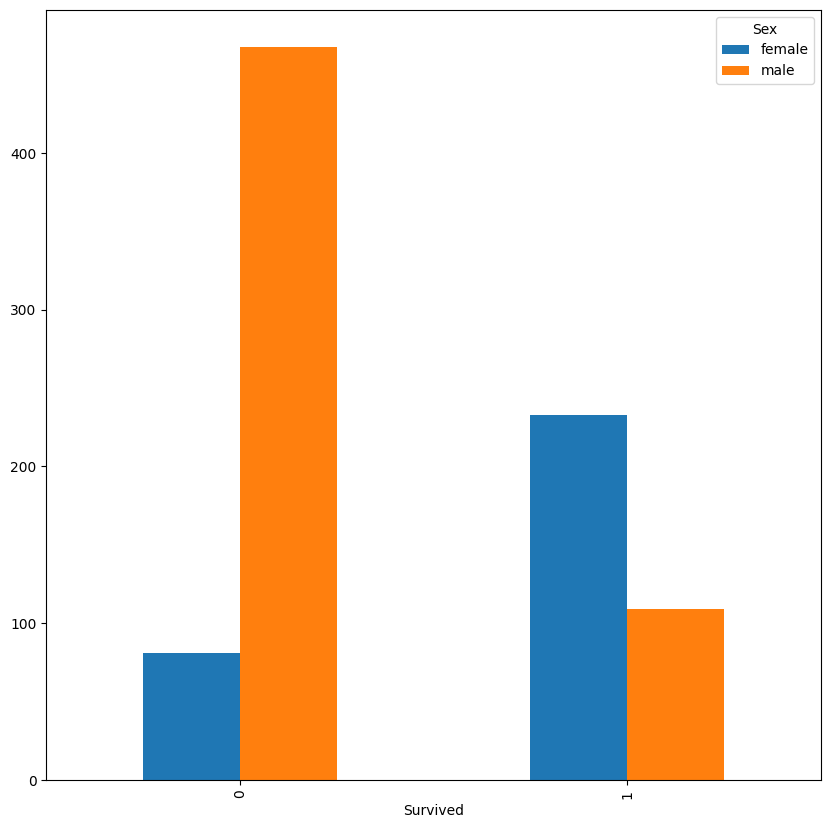

In [ ]:
df.groupby(
    ['Survived', 'Sex']
)['PassengerId'].count().unstack().plot(kind ='bar', figsize = (10, 10))

#### Survival rate depending on Ticket class

In [ ]:
df.groupby(['Survived', 'Pclass'])['PassengerId'].agg(
    ['count']
)

count
Survived Pclass       
0        1          80
         2          97
         3         372
1        1         136
         2          87
         3         119

In [ ]:
df.groupby(['Survived', 'Pclass'])['PassengerId'].count().unstack()

Pclass,1,2,3
Survived,,,
0,80,97,372
1,136,87,119


<Axes: xlabel='Survived'>

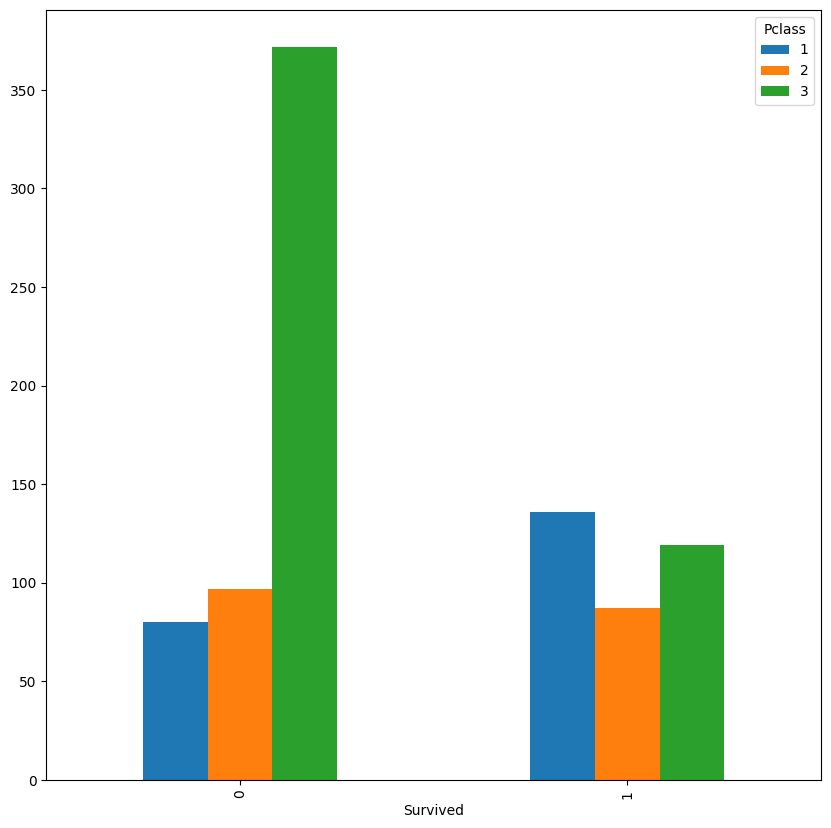

In [ ]:
df.groupby(
    ['Survived', 'Pclass']
)['PassengerId'].count().unstack().plot(kind ='bar', figsize = (10, 10))

#### Survival rate depending on Age

In [ ]:
df['generation'] = pd.cut(df['Age'], 8)

In [ ]:
# [(0.34, 10.368]
# (10.368, 20.315]
# (20.315, 30.263]
# (30.263, 40.21]
# (40.21, 50.158]
# (50.158, 60.105]
# (60.105, 70.052]
# (70.052, 80.0]]

pd.cut(df['Age'], 8)

,Age
0,"(20.315, 30.263]"
1,"(30.263, 40.21]"
2,"(20.315, 30.263]"
3,"(30.263, 40.21]"
4,"(30.263, 40.21]"
...,...
886,"(20.315, 30.263]"
887,"(10.368, 20.315]"
888,NaN
889,"(20.315, 30.263]"


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,generation
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,"(20.315, 30.263]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,"(30.263, 40.21]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,"(20.315, 30.263]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,"(30.263, 40.21]"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,"(30.263, 40.21]"


/tmp/ipykernel_1394/1201001995.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


<Axes: xlabel='Survived'>

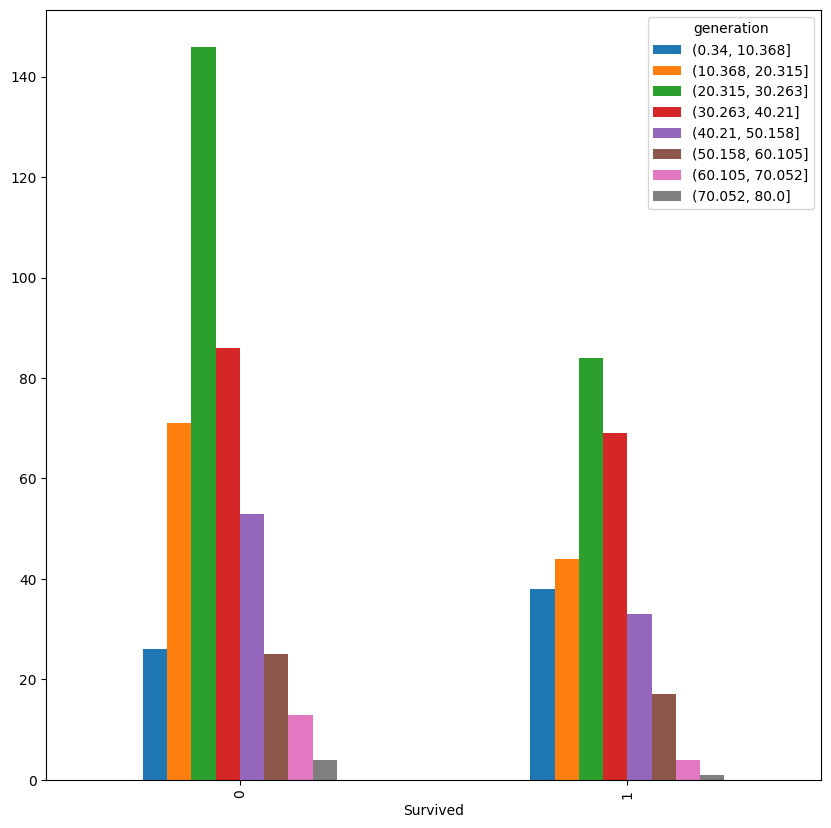

In [ ]:
df.groupby(
    ['Survived', 'generation']
)['PassengerId'].count().unstack().plot(kind ='bar', figsize = (10, 10))

#### Survival rate depending on Fare

In [ ]:
df['fare_category'] = pd.cut(df['Fare'], 12)

In [ ]:
pd.cut(df['Fare'], 10)

,Fare
0,"(-0.512, 51.233]"
1,"(51.233, 102.466]"
2,"(-0.512, 51.233]"
3,"(51.233, 102.466]"
4,"(-0.512, 51.233]"
...,...
886,"(-0.512, 51.233]"
887,"(-0.512, 51.233]"
888,"(-0.512, 51.233]"
889,"(-0.512, 51.233]"


/tmp/ipykernel_1394/2369799790.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


<Axes: xlabel='Survived'>

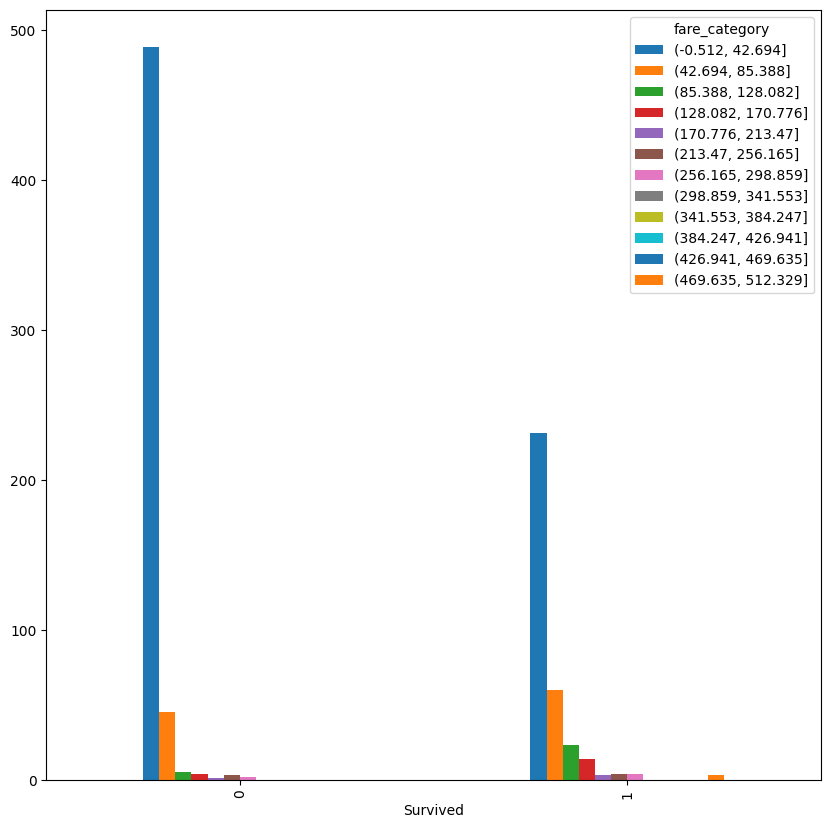

In [ ]:
df.groupby(
    ['Survived', 'fare_category']
)['PassengerId'].count().unstack().plot(kind ='bar', figsize = (10, 10))

#### What about correlations?

In [ ]:
df[['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch']].corr()

,Survived,Pclass,Age,Fare,SibSp,Parch
Survived,1.000000,-0.338481,-0.077221,0.257307,-0.035322,0.081629
Pclass,-0.338481,1.000000,-0.369226,-0.549500,0.083081,0.018443
Age,-0.077221,-0.369226,1.000000,0.096067,-0.308247,-0.189119
Fare,0.257307,-0.549500,0.096067,1.000000,0.159651,0.216225
SibSp,-0.035322,0.083081,-0.308247,0.159651,1.000000,0.414838
Parch,0.081629,0.018443,-0.189119,0.216225,0.414838,1.000000


In [ ]:
df[['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch']].corr().style.background_gradient(cmap='coolwarm')

,Survived,Pclass,Age,Fare,SibSp,Parch
Survived,1.000000,-0.338481,-0.077221,0.257307,-0.035322,0.081629
Pclass,-0.338481,1.000000,-0.369226,-0.549500,0.083081,0.018443
Age,-0.077221,-0.369226,1.000000,0.096067,-0.308247,-0.189119
Fare,0.257307,-0.549500,0.096067,1.000000,0.159651,0.216225
SibSp,-0.035322,0.083081,-0.308247,0.159651,1.000000,0.414838
Parch,0.081629,0.018443,-0.189119,0.216225,0.414838,1.000000


## Questions:

##### Cabins on the port side have an even number and cabins on the starboard side have an odd number.

#### For example, cabin B57 is located on the starboard side.

#### Which side of the boat is better to be on?


#### The deck number of the boat is indicated on the ticket. Cabin B57 is located on deck B. Which deck is best to be on?

#### Where is the best place to be on the boat in general?

#### Is there a link between the number of parents/family on the boat and chances of survival?

In [ ]:
df['Cabin'].str.extract(r'(\d+)')


,0
0,NaN
1,85
2,NaN
3,123
4,NaN
...,...
886,NaN
887,42
888,NaN
889,148


In [ ]:
df.shape[0]

index = pd.to_numeric(df['Cabin'].str.extract(r'(\d+)', expand=False), errors='coerce')

index_even = df.index[index % 2 == 0].tolist()
print(index_even)

index_odd = df.index[index % 2 == 1].tolist()
print(index_odd)

Index([  6,  10,  21,  23,  31,  54,  55,  61,  97, 102,
       ...
       806, 809, 815, 829, 849, 853, 867, 879, 887, 889],
      dtype='int64', length=108)
[1, 3, 11, 27, 52, 62, 66, 75, 88, 92, 96, 123, 128, 136, 137, 166, 170, 174, 177, 209, 218, 224, 230, 248, 252, 257, 262, 268, 269, 275, 284, 291, 303, 307, 311, 318, 332, 341, 345, 356, 366, 369, 438, 452, 457, 462, 484, 486, 487, 504, 505, 512, 516, 520, 527, 539, 558, 571, 572, 587, 609, 621, 627, 630, 641, 645, 671, 679, 681, 689, 699, 715, 716, 717, 730, 737, 740, 742, 751, 759, 765, 772, 779, 796, 820, 823, 835, 839, 857, 862, 871, 872]


In [ ]:
df['binCabin'] = index % 2

df_filtre = df.dropna(subset='binCabin')

df_filtre[['Survived', 'binCabin']].corr()


,Survived,binCabin
Survived,1.000000,0.135693
binCabin,0.135693,1.000000


(binCabin=1) (on the starboard) et (Survivre=1) sont corrélés à +0.13 donc pas une grosse correlation positive.

#### What is the typical profile of the person who will survive the shipwreck?

#### What is the typical profile of the person who will not survive the shipwreck?